In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# CIFAR10 dataset (colored images, 32x32)
transform = transforms.Compose([
    transforms.ToTensor(),
])
trainset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)    

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder: Conv -> smaller spatial size, more channels
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),# 128x4x4
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128*4*4, latent_dim)
        self.fc_logvar = nn.Linear(128*4*4, latent_dim)

        # Decoder: Fully connected -> ConvTranspose layers
        self.fc_dec = nn.Linear(latent_dim, 128*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), # 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # 3x32x32
            nn.Sigmoid()  # output in [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        h = self.encoder(x).view(x.size(0), -1)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        # Decode
        h_dec = self.fc_dec(z).view(-1, 128, 4, 4)
        x_recon = self.decoder(h_dec)
        return x_recon, mu, logvar


In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction term (binary cross-entropy)
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    # KL divergence
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + kl_div) / x.size(0)

In [6]:
vae = VAE(latent_dim=64).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(10):
    vae.train()
    total_loss = 0
    for imgs, _ in trainloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        recon, mu, logvar = vae(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Loss: {total_loss / len(trainloader):.4f}")

    # Show reconstructions from the first batch
    if epoch % 2 == 0:
        vutils.save_image(torch.cat([imgs[:8], recon[:8]]),
                          f"recon_epoch{epoch}.png", nrow=8)


Epoch [1/10], Loss: 110.4053
Epoch [2/10], Loss: 81.7298
Epoch [3/10], Loss: 78.7576
Epoch [4/10], Loss: 77.6771
Epoch [5/10], Loss: 76.8037
Epoch [6/10], Loss: 76.2613
Epoch [7/10], Loss: 75.8151
Epoch [8/10], Loss: 75.3740
Epoch [9/10], Loss: 75.1693
Epoch [10/10], Loss: 75.0070


In [7]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, vae.latent_dim).to(device)
    samples = vae.decoder(vae.fc_dec(z).view(-1, 128, 4, 4))
    vutils.save_image(samples, "samples.png", nrow=8)


In [8]:
def transpose(image):
    image = torch.transpose(image, 0, 2)
    image = torch.transpose(image, 0, 1)
    return image

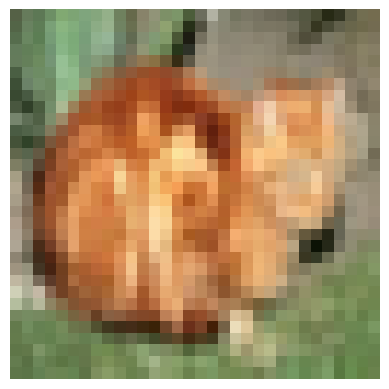

In [17]:
import matplotlib.pyplot as plt

image = trainset[1100][0]
# print(classes[image.get_label_1()] + " + " + classes[image.get_label_2()])
plt.imshow(transpose(image))
plt.axis("off")
plt.show()